# Sprint 2 - Data Cleaning & Feature Engineering

**Project:** AutoGuard AI - Insurance Underwriting Assistant  
**Scope:** data cleaning and feature engineering only  
**Dataset:** `data/raw/train.csv`, `data/raw/test.csv`  
**Target:** `is_claim`

This notebook prepares the highest-quality offline modeling dataset possible for the current sprint without training models, building production preprocessing pipelines, touching backend/frontend, or starting Sprint 3.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from ml_pipeline import data_analyst as da
from ml_pipeline import data_encoder as enc

plt.style.use('ggplot')
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 200)

In [2]:
train_df = da.load_train_data()
test_df = da.load_test_data()
review_df = enc.build_feature_review_frame(train_df)

print('Raw train shape:', train_df.shape)
print('Feature review shape:', review_df.shape)
print('Derived feature columns added:', enc.DERIVED_FEATURE_COLUMNS)

Raw train shape: (58592, 44)
Feature review shape: (58592, 53)
Derived feature columns added: ['torque_nm', 'torque_rpm', 'power_bhp', 'power_rpm', 'power_to_weight', 'torque_to_weight', 'vehicle_volume_proxy', 'safety_feature_count', 'parking_assist_score']


## Phase 1 - Feature Audit

In [3]:
raw_audit = enc.raw_feature_audit_table(train_df)
engineered_inventory = enc.engineered_feature_inventory(review_df)
audit_counts = raw_audit['feature_class'].value_counts().rename_axis('feature_class').reset_index(name='count')

display(audit_counts)
display(raw_audit)
display(engineered_inventory)

,feature_class,count
0,Binary,19
1,Numerical,14
2,Categorical,9
3,Identifier,1
4,Target,1


,feature,feature_class,dtype,unique_values,derived_candidate_outputs
0,policy_id,Identifier,str,58592,
1,policy_tenure,Numerical,float64,58592,
2,age_of_car,Numerical,float64,49,
3,age_of_policyholder,Numerical,float64,75,
4,area_cluster,Categorical,str,22,
5,population_density,Numerical,int64,22,
6,make,Categorical,int64,5,
7,segment,Categorical,str,6,
8,model,Categorical,str,11,
9,fuel_type,Categorical,str,3,


,feature,feature_class,dtype,unique_values
0,torque_nm,Derived Candidate,float64,8
1,torque_rpm,Derived Candidate,float64,8
2,power_bhp,Derived Candidate,float64,9
3,power_rpm,Derived Candidate,float64,5
4,power_to_weight,Derived Candidate,float64,10
5,torque_to_weight,Derived Candidate,float64,10
6,vehicle_volume_proxy,Derived Candidate,int64,11
7,safety_feature_count,Derived Candidate,int64,7
8,parking_assist_score,Derived Candidate,int64,2


### Feature Audit Interpretation

The raw dataset contains:

- 1 identifier
- 1 target
- 14 numerical features
- 19 binary features
- 9 non-binary categorical features

The two structured text features, `max_torque` and `max_power`, are retained in the raw data audit but explicitly treated as transform-and-replace candidates because they can be parsed into more model-ready numeric fields.


## Phase 2 - Parse Structured Text Features

In [4]:
parsed_validation = enc.validate_parsed_spec_features(train_df)
parsed_preview = review_df[['max_torque', 'torque_nm', 'torque_rpm', 'max_power', 'power_bhp', 'power_rpm']].head(10)

display(parsed_validation)
display(parsed_preview)

,raw_feature,derived_features,source_unique_values,row_count,parsed_null_count,success_rate,min_primary,max_primary,min_secondary,max_secondary
0,max_torque,"torque_nm, torque_rpm",9,58592,0,100.0,60.00,250.00,1750.0,4400.0
1,max_power,"power_bhp, power_rpm",9,58592,0,100.0,40.36,118.36,3600.0,6000.0


,max_torque,torque_nm,torque_rpm,max_power,power_bhp,power_rpm
0,60Nm@3500rpm,60.0,3500.0,40.36bhp@6000rpm,40.36,6000.0
1,60Nm@3500rpm,60.0,3500.0,40.36bhp@6000rpm,40.36,6000.0
2,60Nm@3500rpm,60.0,3500.0,40.36bhp@6000rpm,40.36,6000.0
3,113Nm@4400rpm,113.0,4400.0,88.50bhp@6000rpm,88.50,6000.0
4,91Nm@4250rpm,91.0,4250.0,67.06bhp@5500rpm,67.06,5500.0
5,250Nm@2750rpm,250.0,2750.0,113.45bhp@4000rpm,113.45,4000.0
6,200Nm@3000rpm,200.0,3000.0,88.77bhp@4000rpm,88.77,4000.0
7,113Nm@4400rpm,113.0,4400.0,88.50bhp@6000rpm,88.50,6000.0
8,250Nm@2750rpm,250.0,2750.0,113.45bhp@4000rpm,113.45,4000.0
9,113Nm@4400rpm,113.0,4400.0,88.50bhp@6000rpm,88.50,6000.0


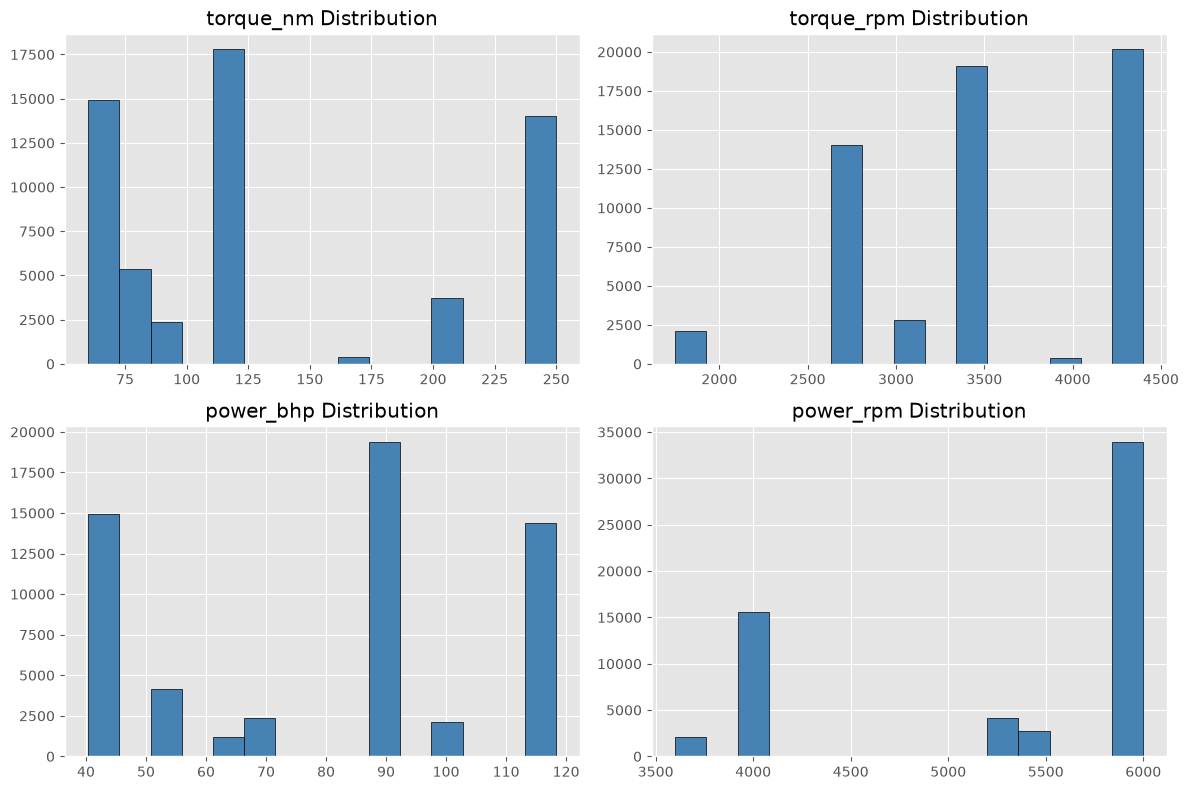

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()
plot_columns = ['torque_nm', 'torque_rpm', 'power_bhp', 'power_rpm']
for ax, column in zip(axes, plot_columns):
    ax.hist(review_df[column], bins=15, color='steelblue', edgecolor='black')
    ax.set_title(f'{column} Distribution')
plt.tight_layout()
plt.show()

### Parsing Assumptions

- `max_torque` follows the pattern `valueNm@rpm`
- `max_power` follows the pattern `valuebhp@rpm`
- units are consistent across the dataset
- one row contains one maximum torque value and one maximum power value

### Extraction Quality

- Parsing succeeded on all training rows.
- No nulls were introduced in `torque_nm`, `torque_rpm`, `power_bhp`, or `power_rpm`.
- The extracted ranges are plausible for the portfolio represented in the data.


## Phase 3 - Binary Feature Standardization

In [6]:
yes_no_validation = enc.validate_yes_no_columns(train_df)
binary_mapping_table = pd.DataFrame({'raw_value': list(enc.YES_NO_MAPPING.keys()), 'binary_value': list(enc.YES_NO_MAPPING.values())})
standardized_preview = review_df[da.YES_NO_FEATURES].head(5)

display(yes_no_validation)
display(binary_mapping_table)
display(standardized_preview)

,feature,observed_values,invalid_values,invalid_count
0,is_esc,"No, Yes",,0
1,is_adjustable_steering,"No, Yes",,0
2,is_tpms,"No, Yes",,0
3,is_parking_sensors,"No, Yes",,0
4,is_parking_camera,"No, Yes",,0
5,is_front_fog_lights,"No, Yes",,0
6,is_rear_window_wiper,"No, Yes",,0
7,is_rear_window_washer,"No, Yes",,0
8,is_rear_window_defogger,"No, Yes",,0
9,is_brake_assist,"No, Yes",,0


,raw_value,binary_value
0,No,0
1,Yes,1


,is_esc,is_adjustable_steering,is_tpms,is_parking_sensors,is_parking_camera,is_front_fog_lights,is_rear_window_wiper,is_rear_window_washer,is_rear_window_defogger,is_brake_assist,is_power_door_locks,is_central_locking,is_power_steering,is_driver_seat_height_adjustable,is_day_night_rear_view_mirror,is_ecw,is_speed_alert
0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,1
1,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,1
2,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,1
3,1,1,0,1,1,1,0,0,1,1,1,1,1,1,1,1,1
4,0,0,0,0,1,0,0,0,0,0,1,1,1,0,1,1,1


### Binary Standardization Interpretation

All audited Yes/No fields contain only `Yes` and `No`, so a consistent mapping of `Yes -> 1` and `No -> 0` can be applied without ambiguity.

This sprint standardizes those values for offline dataset preparation only. It does **not** define a production preprocessing pipeline.


## Phase 4 - Feature Engineering

In [7]:
engineered_features = review_df[enc.DERIVED_FEATURE_COLUMNS]
engineered_summary = engineered_features.describe().T
engineered_evaluation = enc.engineered_feature_evaluation(review_df)

display(engineered_summary)
display(engineered_evaluation)

,count,mean,std,min,25%,50%,75%,max
torque_nm,58592.0,1.344509e+02,7.314679e+01,6.000000e+01,6.000000e+01,1.130000e+02,2.000000e+02,2.500000e+02
torque_rpm,58592.0,3.533176e+03,7.259607e+02,1.750000e+03,2.750000e+03,3.500000e+03,4.400000e+03,4.400000e+03
power_bhp,58592.0,7.897677e+01,2.769926e+01,4.036000e+01,4.036000e+01,8.850000e+01,9.789000e+01,1.183600e+02
power_rpm,58592.0,5.307163e+03,9.167708e+02,3.600000e+03,4.000000e+03,6.000000e+03,6.000000e+03,6.000000e+03
power_to_weight,58592.0,5.602117e-02,1.570612e-02,3.405907e-02,3.405907e-02,6.595930e-02,6.629213e-02,9.313987e-02
torque_to_weight,58592.0,9.305197e-02,4.044428e-02,5.063291e-02,5.063291e-02,8.464419e-02,1.453488e-01,1.902950e-01
vehicle_volume_proxy,58592.0,1.008774e+10,1.748449e+09,7.698283e+09,7.698283e+09,1.020674e+10,1.066473e+10,1.258460e+10
safety_feature_count,58592.0,4.963988e+00,2.895558e+00,1.000000e+00,2.000000e+00,5.000000e+00,9.000000e+00,9.000000e+00
parking_assist_score,58592.0,1.350133e+00,4.770155e-01,1.000000e+00,1.000000e+00,1.000000e+00,2.000000e+00,2.000000e+00


,feature,information_value,iv_band,correlation_with_target,claim_rate_spread_pct_points
0,power_to_weight,0.005598,Very Low,0.008260,0.884212
1,torque_to_weight,0.005598,Very Low,0.004487,0.760051
2,safety_feature_count,0.004239,Very Low,0.007370,1.293980
3,vehicle_volume_proxy,0.003162,Very Low,0.005949,0.788076
4,parking_assist_score,0.000113,Very Low,0.002588,0.132771


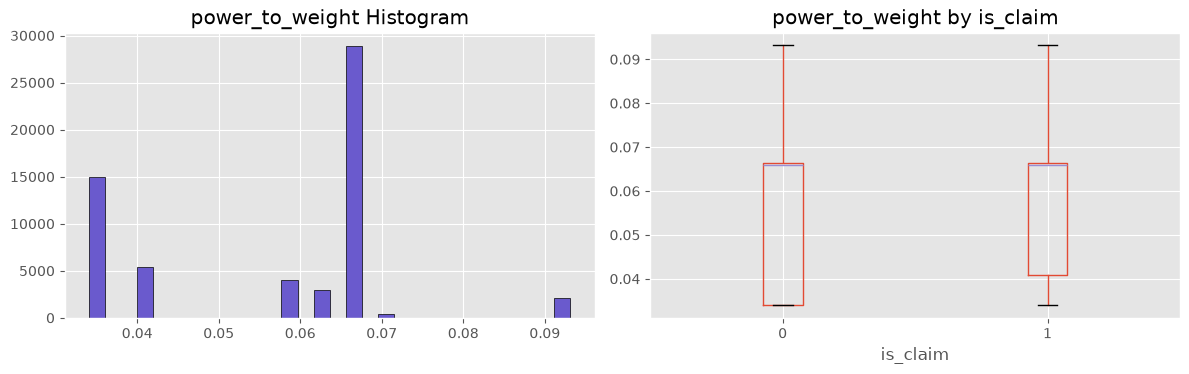

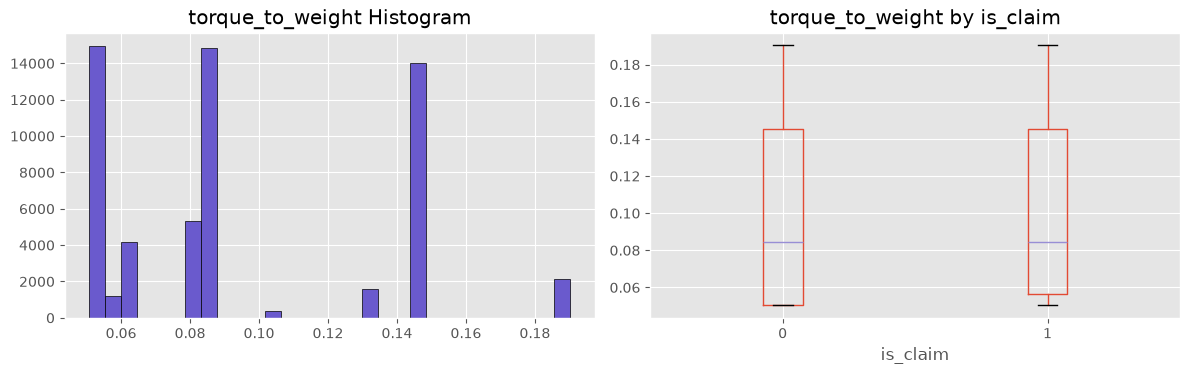

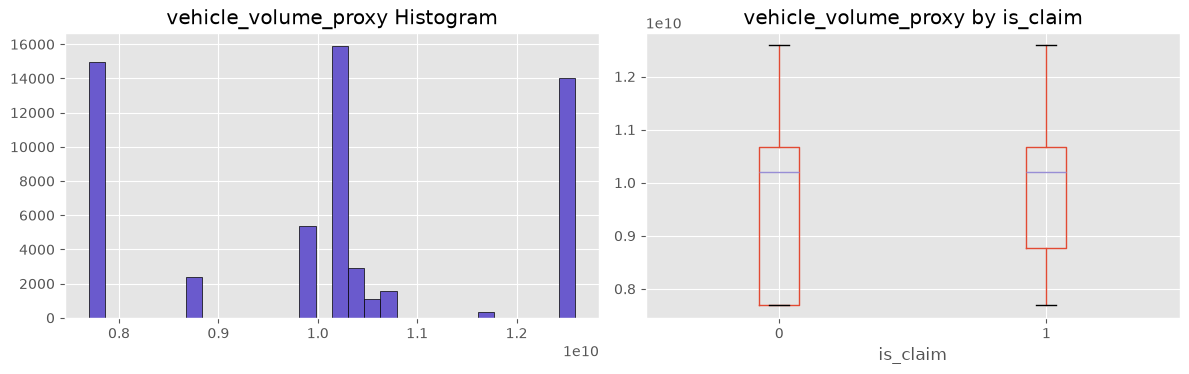

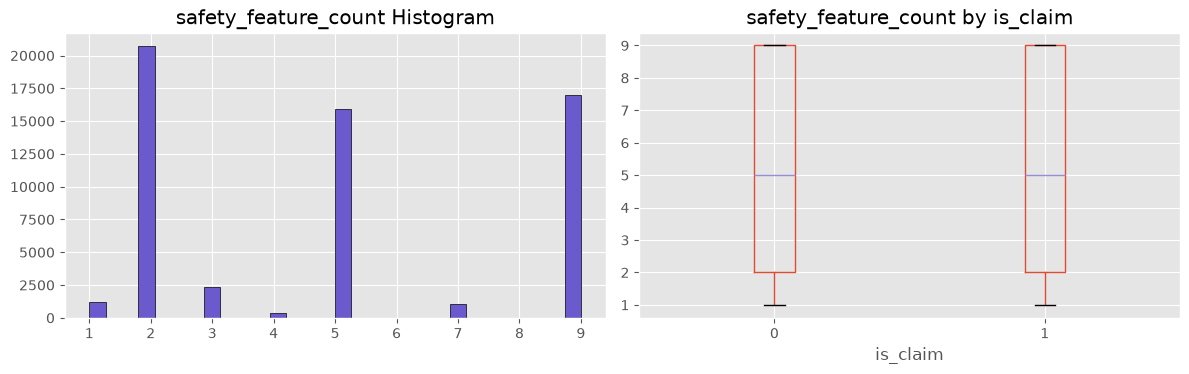

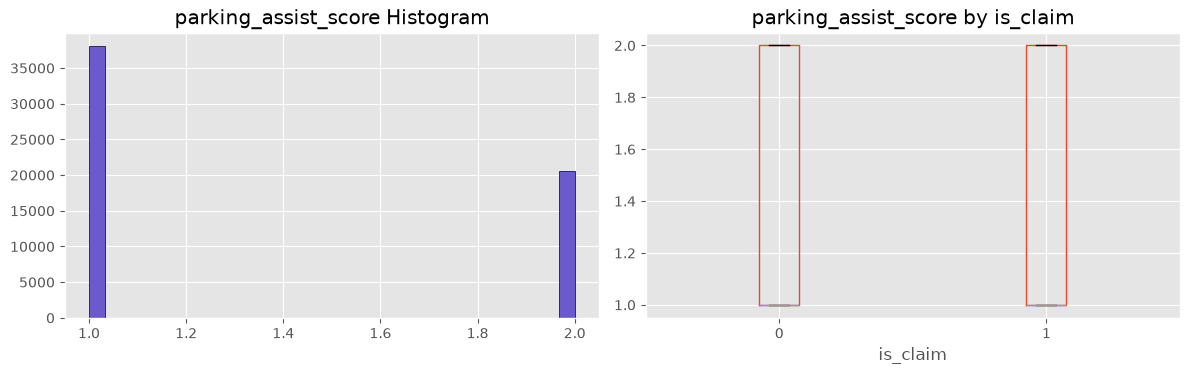

In [8]:
for column in ['power_to_weight', 'torque_to_weight', 'vehicle_volume_proxy', 'safety_feature_count', 'parking_assist_score']:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].hist(review_df[column], bins=30, color='slateblue', edgecolor='black')
    axes[0].set_title(f'{column} Histogram')
    review_df.boxplot(column=column, by=da.TARGET_COLUMN, ax=axes[1])
    axes[1].set_title(f'{column} by is_claim')
    axes[1].figure.suptitle('')
    plt.tight_layout()
    plt.show()

In [9]:
extra_candidates = review_df.copy()
extra_candidates['power_per_displacement'] = extra_candidates['power_bhp'] / extra_candidates['displacement']
extra_candidates['torque_per_displacement'] = extra_candidates['torque_nm'] / extra_candidates['displacement']
extra_candidates['weight_per_volume'] = extra_candidates['gross_weight'] / extra_candidates['vehicle_volume_proxy']

candidate_rows = []
for feature in ['power_per_displacement', 'torque_per_displacement', 'weight_per_volume']:
    candidate_rows.append({
        'feature': feature,
        'information_value': enc.information_value(extra_candidates, feature),
        'correlation_with_target': float(extra_candidates[[feature, da.TARGET_COLUMN]].corr(numeric_only=True).iloc[0, 1]),
    })
extra_candidate_table = pd.DataFrame(candidate_rows)
display(extra_candidate_table.round(6))

,feature,information_value,correlation_with_target
0,power_per_displacement,0.005580,0.007448
1,torque_per_displacement,0.005580,0.003013
2,weight_per_volume,0.003782,-0.005947


### Feature Engineering Interpretation

Requested engineered features were created and reviewed:

- `power_to_weight`
- `torque_to_weight`
- `vehicle_volume_proxy`
- `safety_feature_count`
- `parking_assist_score`

In univariate Sprint 2 review, these features show modest standalone signal. `power_to_weight` and `torque_to_weight` are the strongest of the requested derived features by information value, but all remain in the ?Very Low? IV band by themselves.

Additional candidate ratios such as `power_per_displacement`, `torque_per_displacement`, and `weight_per_volume` were investigated, but they did not show clearly better univariate signal than the requested engineered features, so they are documented as investigated rather than adopted.


## Phase 5 - Outlier Analysis

In [10]:
outlier_table = enc.outlier_analysis_table(review_df)
display(outlier_table)

,feature,min,p01,q1,median,q3,p99,max,skewness,iqr_outlier_count,iqr_outlier_percentage,impossible_count,recommended_action
0,policy_tenure,2.735273e-03,1.001861e-02,2.102496e-01,5.737917e-01,1.039104e+00,1.241190e+00,1.396641e+00,0.053588,0,0.000000,0,Keep
1,age_of_car,0.000000e+00,0.000000e+00,2.000000e-02,6.000000e-02,1.100000e-01,2.100000e-01,1.000000e+00,1.094081,269,0.459107,0,Keep
2,age_of_policyholder,2.884615e-01,2.884615e-01,3.653846e-01,4.519231e-01,5.480769e-01,7.884615e-01,1.000000e+00,0.640049,221,0.377185,0,Keep
3,population_density,2.900000e+02,2.900000e+02,6.112000e+03,8.794000e+03,2.700300e+04,7.343000e+04,7.343000e+04,1.674178,3647,6.224399,0,Transform
4,airbags,1.000000e+00,1.000000e+00,2.000000e+00,2.000000e+00,6.000000e+00,6.000000e+00,6.000000e+00,0.905946,0,0.000000,0,Keep
5,displacement,7.960000e+02,7.960000e+02,7.960000e+02,1.197000e+03,1.493000e+03,1.498000e+03,1.498000e+03,-0.105317,0,0.000000,0,Keep
6,cylinder,3.000000e+00,3.000000e+00,3.000000e+00,4.000000e+00,4.000000e+00,4.000000e+00,4.000000e+00,-0.525074,0,0.000000,0,Keep
7,gear_box,5.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00,6.000000e+00,6.000000e+00,1.183054,14381,24.544306,0,Keep
8,turning_radius,4.500000e+00,4.500000e+00,4.600000e+00,4.800000e+00,5.000000e+00,5.200000e+00,5.200000e+00,0.420983,0,0.000000,0,Keep
9,length,3.445000e+03,3.445000e+03,3.445000e+03,3.845000e+03,3.995000e+03,4.300000e+03,4.300000e+03,0.145801,0,0.000000,0,Keep


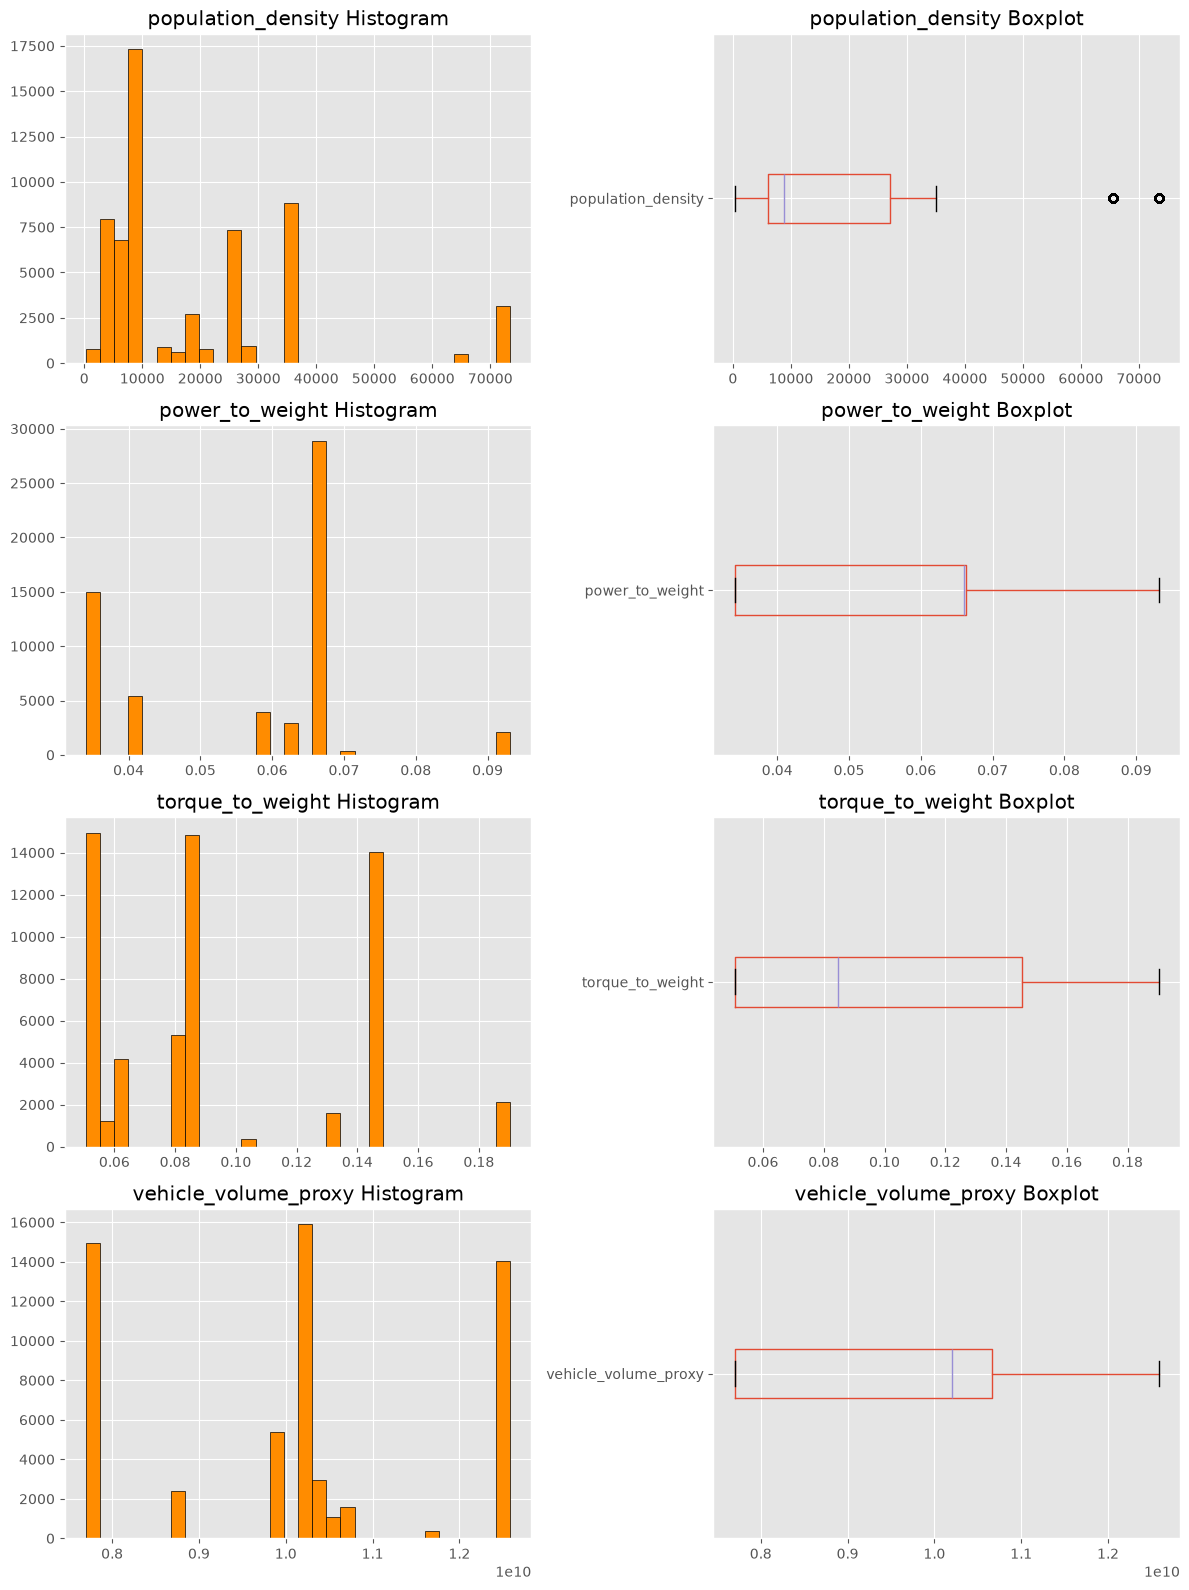

In [11]:
focus_outliers = ['population_density', 'power_to_weight', 'torque_to_weight', 'vehicle_volume_proxy']
fig, axes = plt.subplots(len(focus_outliers), 2, figsize=(12, 4 * len(focus_outliers)))
for idx, column in enumerate(focus_outliers):
    axes[idx, 0].hist(review_df[column], bins=30, color='darkorange', edgecolor='black')
    axes[idx, 0].set_title(f'{column} Histogram')
    review_df.boxplot(column=column, ax=axes[idx, 1], vert=False)
    axes[idx, 1].set_title(f'{column} Boxplot')
plt.tight_layout()
plt.show()

### Outlier Interpretation

- No impossible values were detected in the audited raw or derived numerical fields.
- `population_density` is the clearest candidate for transformation because of its right-skew and visible high-end tail.
- The ratio features `power_to_weight` and `torque_to_weight` are plausible, but are better treated as cap-review candidates than raw removals.
- `vehicle_volume_proxy` is mathematically valid but scale-heavy, so it is better handled as a transform candidate than as a raw unscaled feature.
- No row-removal action is justified in Sprint 2.


## Phase 6 - Feature Quality Assessment

In [12]:
duplicate_pairs = enc.exact_duplicate_feature_pairs(review_df)
quality_table = enc.feature_quality_assessment(review_df)
action_counts = quality_table['recommended_action'].value_counts().rename_axis('action').reset_index(name='count')

display(duplicate_pairs)
display(action_counts)
display(quality_table)

,left_feature,right_feature
0,is_rear_window_wiper,is_rear_window_washer
1,is_power_door_locks,is_central_locking
2,is_power_door_locks,is_ecw
3,is_central_locking,is_ecw


,action,count
0,Keep,33
1,Transform,13
2,Drop,6


,feature,feature_class,information_value,iv_band,business_relevance,modeling_relevance,recommended_action
0,policy_id,Identifier,0.324891,Strong,Low,Low,Drop
1,max_torque,Categorical,0.005580,Very Low,Medium,Low,Drop
2,max_power,Categorical,0.005580,Very Low,Medium,Low,Drop
3,is_central_locking,Binary,0.000738,Very Low,Low,Low,Drop
4,is_ecw,Binary,0.000738,Very Low,Low,Low,Drop
5,is_rear_window_washer,Binary,0.000119,Very Low,Medium,Low,Drop
6,policy_tenure,Numerical,0.120494,Medium,High,High,Keep
7,age_of_car,Numerical,0.018605,Very Low,High,Medium,Keep
8,age_of_policyholder,Numerical,0.010702,Very Low,High,Medium,Keep
9,width,Numerical,0.005598,Very Low,Medium,Low,Keep


C:\Users\97252\AppData\Local\Temp\ipykernel_44308\2615356972.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(top_quality['feature'], rotation=75, ha='right')


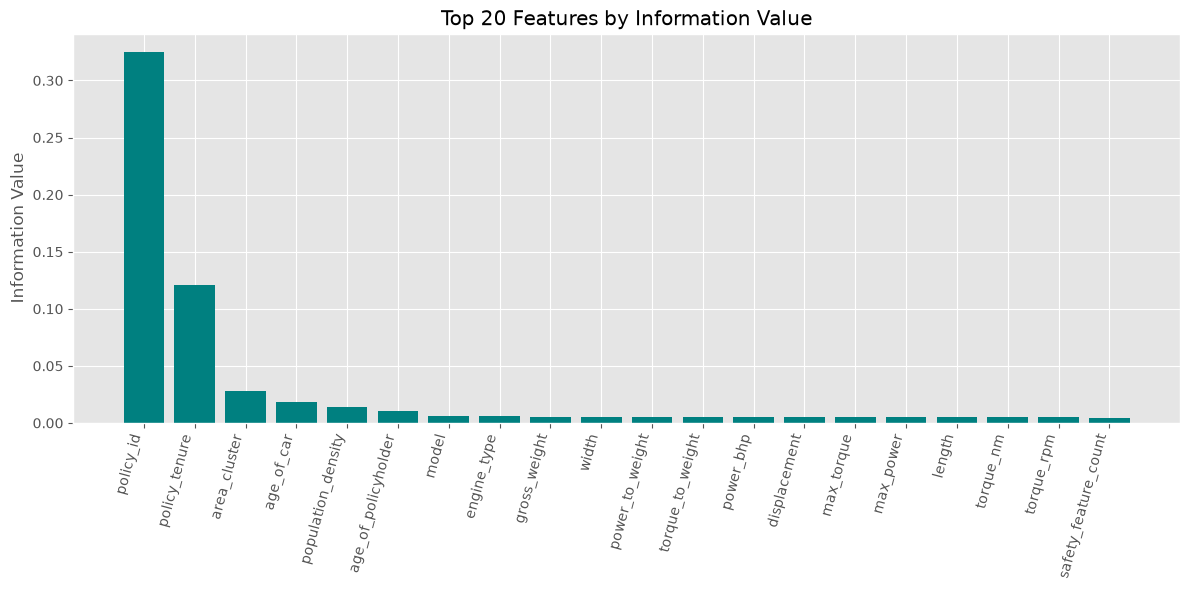

In [13]:
top_quality = quality_table.sort_values('information_value', ascending=False).head(20)
fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(top_quality['feature'], top_quality['information_value'], color='teal')
ax.set_title('Top 20 Features by Information Value')
ax.set_ylabel('Information Value')
ax.set_xticklabels(top_quality['feature'], rotation=75, ha='right')
plt.tight_layout()
plt.show()

### Quality Assessment Interpretation

Key outcomes from the keep/transform/drop review:

- `policy_id` is flagged for removal because it is an identifier and would create leakage or memorization risk.
- Raw `max_torque` and `max_power` are flagged for removal **after** replacement by their parsed numeric components.
- `population_density`, core categorical fields, and the scale-heavy ratio/volume features are retained as transform candidates rather than raw drop candidates.
- Exact duplicate binary pairs exist in the real data, including `is_rear_window_wiper` = `is_rear_window_washer` and a convenience-feature bundle where `is_power_door_locks`, `is_central_locking`, and `is_ecw` are exact duplicates. Keeping all of them would add redundancy without new information.


## Phase 7 - Sprint Conclusion

In [14]:
clean_inventory = enc.clean_feature_inventory(train_df)
features_for_modeling = quality_table[quality_table['recommended_action'].isin(['Keep', 'Transform'])]['feature'].tolist()
features_for_removal = quality_table[quality_table['recommended_action'] == 'Drop']['feature'].tolist()
transform_features = quality_table[quality_table['recommended_action'] == 'Transform']['feature'].tolist()

print('Features recommended for modeling:', len(features_for_modeling))
print('Features recommended for removal:', len(features_for_removal))
print('Features requiring transformation:', len(transform_features))

display(clean_inventory)
print('Removal list:', features_for_removal)
print('Transform list:', transform_features)

Features recommended for modeling: 46
Features recommended for removal: 6
Features requiring transformation: 13


,feature,dtype,unique_values
0,policy_tenure,float64,58592
1,age_of_car,float64,49
2,age_of_policyholder,float64,75
3,width,int64,10
4,gross_weight,int64,10
5,displacement,int64,9
6,power_bhp,float64,9
7,length,int64,9
8,torque_nm,float64,8
9,torque_rpm,float64,8


Removal list: ['policy_id', 'max_torque', 'max_power', 'is_central_locking', 'is_ecw', 'is_rear_window_washer']
Transform list: ['area_cluster', 'population_density', 'model', 'engine_type', 'power_to_weight', 'torque_to_weight', 'segment', 'vehicle_volume_proxy', 'fuel_type', 'steering_type', 'make', 'rear_brakes_type', 'transmission_type']


### Sprint 2 Summary

1. **Clean feature inventory:** produced from the cleaned feature-review frame.
2. **Engineered feature inventory:** all requested derived fields were created and validated.
3. **Features recommended for modeling:** all keep/transform features in the quality table.
4. **Features recommended for removal:**
   - `policy_id`
   - raw `max_torque`
   - raw `max_power`
   - `is_rear_window_washer`
   - `is_central_locking`
   - `is_ecw`
5. **Data quality after cleaning:** no nulls or infinite values were introduced into the derived feature set.
6. **Recommendations for Sprint 3:** focus on categorical encoding strategy, skew-aware transformation, scaling design, and replacement of raw torque/power strings with parsed numeric features.

Sprint 2 stops here. No preprocessing pipeline, split strategy, or model training starts in this notebook.
